In [1]:
## install finrl library if not installed

import pkg_resources
import pip
installedPackages = {pkg.key for pkg in pkg_resources.working_set} # list of installed packages

required = {'pandas','numpy', 'matplotlib','scikit-learn'
            }
missing = required - installedPackages
if missing:

    !pip install pandas
    !pip install numpy
    !pip install matplotlib
    !pip uninstall scikit-learn

<ipython-input-1-f2147164d9ff>:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/usr/local/lib/python3.10/dist-packages/_distutils_hack/__init__.py:31: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("drive/My Drive/Asset_Allocation")

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from pandas_datareader import data as pdr
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from dateutil.relativedelta import relativedelta
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import shap
from sklearn.model_selection import PredefinedSplit
from sklearn.model_selection import  GridSearchCV
from sklearn.linear_model import Ridge
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [5]:
train_df = pd.read_pickle('datasets/train_data_m1_month.pkl')
test_df = pd.read_pickle('datasets/test_data_m1_month.pkl')

In [6]:
#check dates
test_df.Date.min(),test_df.Date.max(),train_df.Date.min(),train_df.Date.max()

(Timestamp('2022-01-01 00:00:00'),
 Timestamp('2024-11-01 00:00:00'),
 Timestamp('2010-01-01 00:00:00'),
 Timestamp('2021-12-01 00:00:00'))

In [7]:
train_df.head()

,Date,Ticker,close,high,low,open,volume,monthly_return,target,monthly_return_6_sma,...,wt2,supertrend_ub,supertrend_lb,vwma_3,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt
4,2010-01-01,AAPL,5.786131,6.495012,5.731602,6.429938,15168994400,-0.088597,0.065396,0.010763,...,104.539884,7.558034,3.840699,6.044047,14764.610000,9.800000,217.488000,0.110000,0.05,1.277312e+07
5,2010-02-01,AAPL,6.164524,6.181093,5.749679,5.795472,10776080000,0.065396,0.148470,0.021690,...,92.697784,7.558034,3.887466,6.059565,14836.471000,9.833333,217.459667,0.140000,0.09,1.291601e+07
6,2010-03-01,AAPL,7.079769,7.154484,6.189526,6.198564,12154172800,0.148470,0.111022,0.042820,...,89.076892,7.558034,4.436671,6.268415,14908.332000,9.866667,217.431333,0.170000,0.13,1.305890e+07
7,2010-04-01,AAPL,7.865777,8.208316,7.011986,7.152376,12367129600,0.111022,-0.016125,0.058491,...,89.838659,7.558034,5.158634,6.881899,14980.193000,9.900000,217.403000,0.200000,0.17,1.320179e+07
8,2010-05-01,AAPL,7.738943,8.070336,6.002742,7.948624,18082654800,-0.016125,-0.020827,0.045715,...,94.397524,10.038551,5.158634,7.261938,15033.997667,9.733333,217.470333,0.193333,0.17,1.332174e+07


In [8]:
#check NaN
train_df.isna().sum().sum(),test_df.isna().sum().sum()

(0, 0)

In [9]:
#Define features
all_features = test_df.drop(columns = ['Date','target','Ticker']).columns.tolist()
data = pd.concat([train_df,test_df])
data.reset_index(drop=True, inplace=True)

In [10]:
unique_trade_date = test_df.Date.unique()
validation_size = 12*4 # Months
training_size = 7 # Years

def rolling_window_training(steps,param_grid,unique_trade_date, data,validation_size, training_size):
  history_all = []
  val_loss = []
  val_r2 = []
  train_loss = []
  train_r2 = []
  test_preds = []
  test_loss = []
  test_r2 = []

  for i in unique_trade_date:
    print(i)
    test_date = i
    validation_date_start = test_date - relativedelta(months=validation_size)
    training_date_start = validation_date_start - relativedelta(years=training_size)
    #print(test_date,validation_date_start)

    #set train, validation, test sets
    train_df = data[(data.Date >=training_date_start) & (data.Date <validation_date_start)]
    val_df =  data[(data.Date >=validation_date_start) & (data.Date <test_date)]
    test_df = data[data.Date == test_date]

    # Create a list where train data indices are -1 and validation data indices are 0
    train_val_indices = train_df.index.tolist() + val_df.index.tolist()
    split_index = [-1 if x in train_df.index else 0 for x in train_val_indices]

    # Use the list to create PredefinedSplit
    pds = PredefinedSplit(test_fold = split_index)

    XlearnT, ylearnT = train_df[all_features],train_df[['target']]
    XvalT, yvalT = val_df[all_features],val_df[['target']]

    model = Pipeline(steps)
    # Use PredefinedSplit in GridSearchCV
    grid_search  = GridSearchCV(estimator = model,
                      cv=pds,
                      param_grid=param_grid,
                      scoring='neg_mean_squared_error')

    # Fit with all data
    grid_search.fit(data.loc[train_val_indices,all_features], data.loc[train_val_indices,['target']])
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_
    print("Best parameters found: ", grid_search.best_params_)

    best_model.fit(XlearnT,ylearnT)
    history = best_model.score(XlearnT,ylearnT)
    preds = best_model.predict(XlearnT)
    val_preds = best_model.predict(XvalT)

    history_all.append(history)

    val_loss.append(root_mean_squared_error(yvalT, val_preds))
    val_r2.append(r2_score(yvalT, val_preds))
    train_loss.append(root_mean_squared_error(ylearnT, preds))
    train_r2.append(r2_score(ylearnT, preds))

    #retrain the model with the all train data
    training_date_start = test_date - relativedelta(years=training_size)
    train_df = data[(data.Date >=training_date_start) & (data.Date <test_date)]

    XlearnT, ylearnT = train_df[all_features],train_df[['target']]
    test_X, test_y = test_df[all_features],test_df[['target']]

    model = Pipeline(steps)
    model.set_params(**best_params)

    model.fit(XlearnT,ylearnT)
    history = model.score(XlearnT,ylearnT)
    preds = model.predict(XlearnT)
    test_pred = model.predict(test_X)

    test_y['pred'] = test_pred
    test_preds.append(test_y['pred'])
    test_loss.append(root_mean_squared_error(test_y['target'], test_y['pred']))
    test_r2.append(r2_score(test_y['target'], test_y['pred']))
  return   history_all,val_r2, train_loss,val_loss, train_r2, test_preds, test_loss ,test_r2, model, XlearnT, XvalT

## Linear Model

2022-01-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-02-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-03-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-04-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-05-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-06-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-07-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-08-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-09-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-10-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-11-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2022-12-01 00:00:00
Best parameters found:  {'regressor__fit_intercept': False}
2023-01-01 00:00:00
Best parameters foun

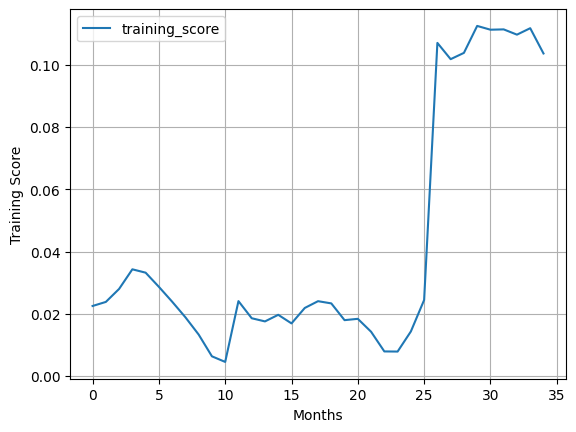

In [11]:
steps=[('scaler', StandardScaler()),
    ('regressor', LinearRegression())]
param_grid = {
    'regressor__fit_intercept': [True, False],
}
history_all,val_r2, train_loss,val_loss, train_r2, test_preds, test_loss ,test_r2, linear_model, XlearnT, XvalT = rolling_window_training(steps,param_grid,unique_trade_date, data,validation_size, training_size)

#performance
test_df.reset_index(drop=True, inplace=True)
test_df['expected_target'] = pd.concat(test_preds).reset_index(drop=True)
print('Average Train Loss= {:.2}'.format(np.mean(train_loss)))
print('Average Validation Loss = {:.2}'.format(np.mean(val_loss)))
print('Test Loss = {:.2}'.format(root_mean_squared_error(test_df['target'], test_df['expected_target'])))
print('Train R2 Min= {:.2}% and Max= {:.2}%'.format(np.min(train_r2)*100,np.max(train_r2)*100))
print('Validation R2 = {:.2}% and Max= {:.2}%'.format(np.mean(val_r2)*100,np.max(val_r2)*100))
print('Test R2 = {:.2}%'.format(r2_score(test_df['target'], test_df['expected_target'])*100))
def plot_loss(history):
  plt.plot(history, label='training_score')
  #plt.ylim([0, 10])
  plt.xlabel('Months')
  plt.ylabel('Training Score')
  plt.legend()
  plt.grid(True)
plot_loss(history_all)

In [12]:
linear_model.named_steps['regressor'].coef_.shape, linear_model.named_steps['regressor'].intercept_, len(all_features)

((1, 95), array([0.01375324]), 95)

PermutationExplainer explainer: 1441it [05:13,  4.60it/s]


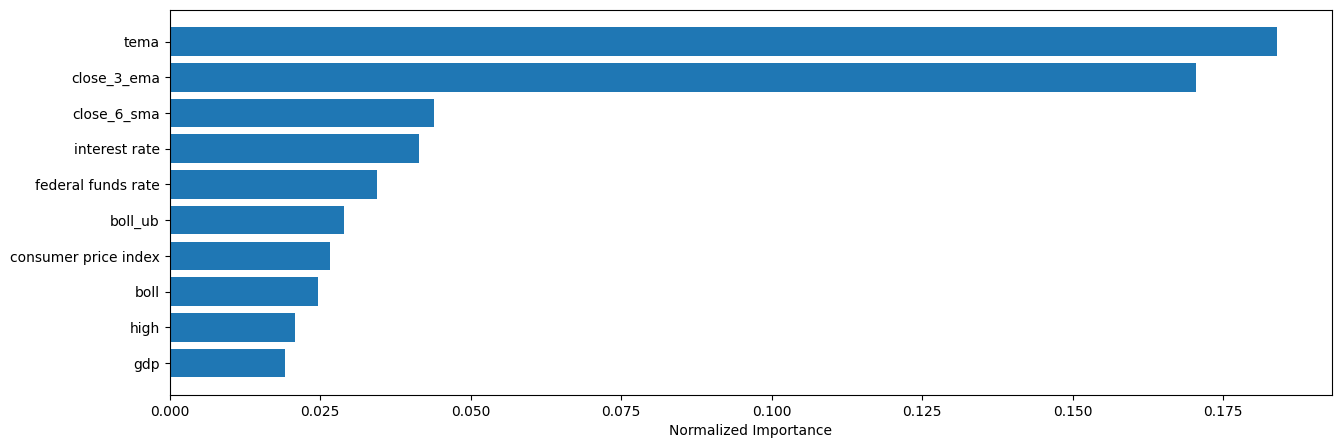

In [13]:
# Use SHAP to explain the model's predictions
explainer = shap.Explainer(linear_model.predict, XlearnT)
shap_values = explainer.shap_values(XvalT)
#Normaliz shap values
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)
# Normalize the feature importances to sum to 1
normalized_importances = mean_abs_shap_values / np.sum(mean_abs_shap_values)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': normalized_importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 normalized feature importances
top_features = importance_df.head(10)
plt.figure(figsize=(15, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Normalized Importance')
#plt.title('Top 10 Normalized Feature Importances')
plt.gca().invert_yaxis()
plt.savefig('linear_importance.png')
plt.show()

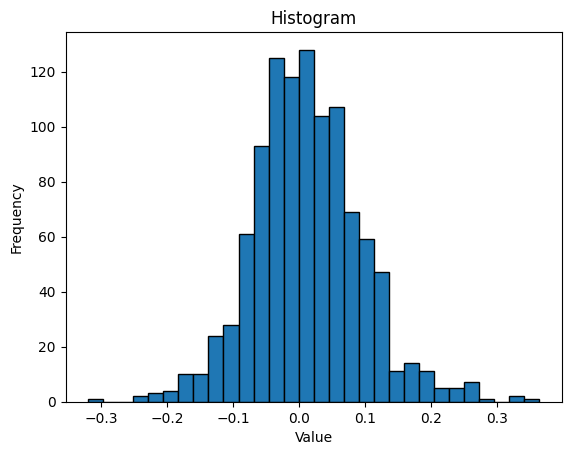

In [14]:
#Check target Distribution
plt.hist(test_df.target, bins=30, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

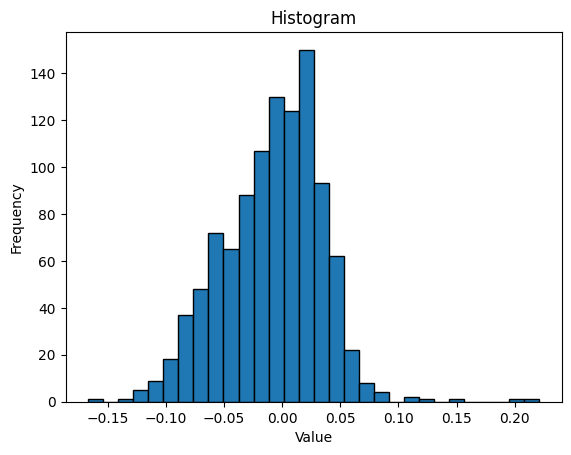

In [15]:
##Check predictions Distribution
plt.hist(test_df.expected_target, bins=30, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

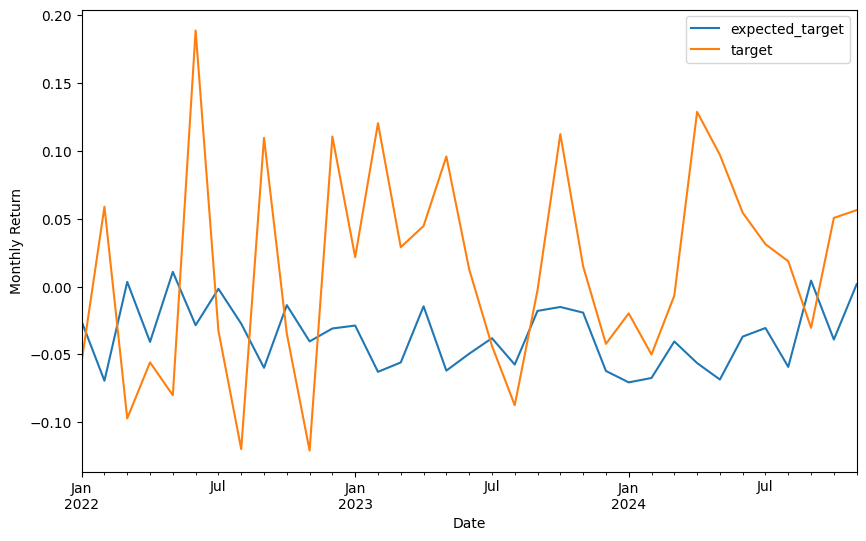

In [16]:
ax = test_df[test_df.Ticker == 'AAPL'].plot.line(y=["expected_target",'target'], x='Date', ylabel='Monthly Return',xlabel = 'Date', figsize=(10, 6))
fig = ax.get_figure()
fig.savefig('Linear_returns.png')

In [17]:
test_df.to_pickle('datasets/test_data_m1_result_linear.pkl')

## Ridge

2022-01-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-02-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-03-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-04-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-05-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-06-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-07-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-08-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-09-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regressor__fit_intercept': False}
2022-10-01 00:00:00
Best parameters found:  {'regressor__alpha': 4, 'regr

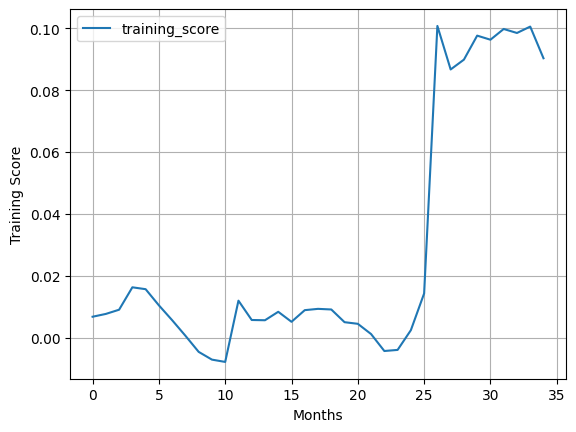

In [18]:
steps=[('scaler', StandardScaler()),
    ('regressor', Ridge())]
param_grid = {
    'regressor__alpha': [ 0.5, 2,4],  # Regularization strength
    'regressor__fit_intercept': [True, False],
}
history_all,val_r2, train_loss,val_loss, train_r2, test_preds, test_loss ,test_r2, ridge_model, XlearnT, XvalT = rolling_window_training(steps,param_grid,unique_trade_date, data,validation_size, training_size)

#performance
test_df.reset_index(drop=True, inplace=True)
test_df['expected_target'] = pd.concat(test_preds).reset_index(drop=True)
print('Average Train Loss= {:.2}'.format(np.mean(train_loss)))
print('Average Validation Loss = {:.2}'.format(np.mean(val_loss)))
print('Test Loss = {:.2}'.format(root_mean_squared_error(test_df['target'], test_df['expected_target'])))
print('Train R2 Min= {:.2}% and Max= {:.2}%'.format(np.min(train_r2)*100,np.max(train_r2)*100))
print('Validation R2 = {:.2}% and Max= {:.2}%'.format(np.mean(val_r2)*100,np.max(val_r2)*100))
print('Test R2 = {:.2}%'.format(r2_score(test_df['target'], test_df['expected_target'])*100))
def plot_loss(history):
  plt.plot(history, label='training_score')
  #plt.ylim([0, 10])
  plt.xlabel('Months')
  plt.ylabel('Training Score')
  plt.legend()
  plt.grid(True)
plot_loss(history_all)

PermutationExplainer explainer: 1441it [05:45,  4.03it/s]


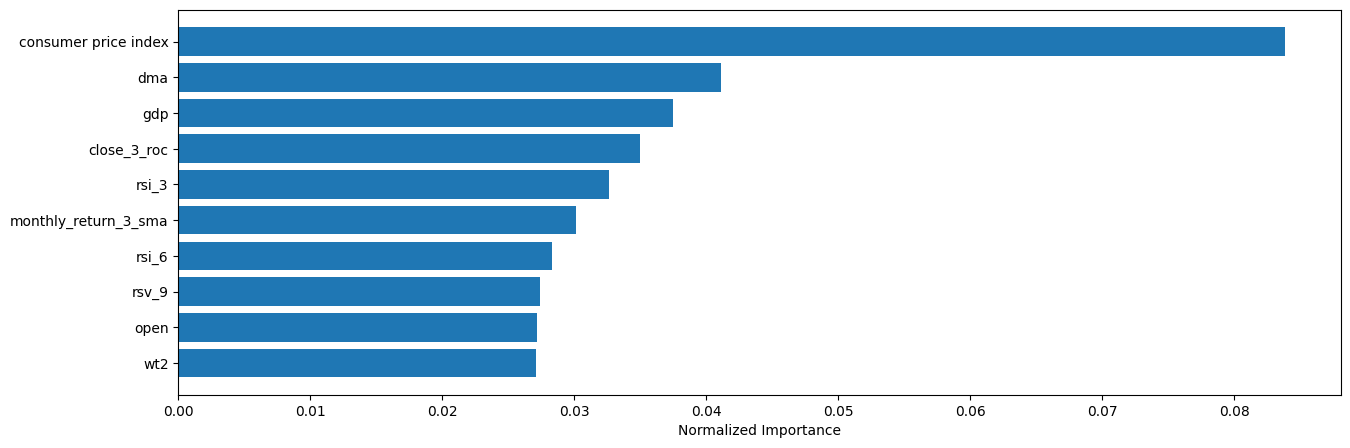

In [19]:
# Use SHAP to explain the model's predictions
explainer = shap.Explainer(ridge_model.predict, XlearnT)
shap_values = explainer.shap_values(XvalT)
#Normaliz shap values
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)
# Normalize the feature importances to sum to 1
normalized_importances = mean_abs_shap_values / np.sum(mean_abs_shap_values)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': normalized_importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 normalized feature importances
top_features = importance_df.head(10)
plt.figure(figsize=(15, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Normalized Importance')
#plt.title('Top 10 Normalized Feature Importances')
plt.gca().invert_yaxis()
plt.savefig('ridge_importance.png')
plt.show()

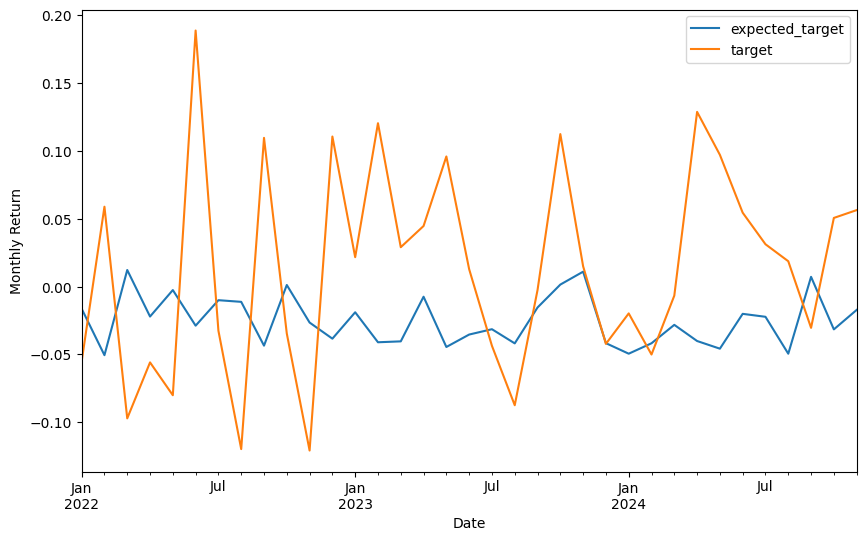

In [20]:
ax = test_df[test_df.Ticker == 'AAPL'].plot.line(y=["expected_target",'target'], x='Date', ylabel='Monthly Return',xlabel = 'Date', figsize=(10, 6))
fig = ax.get_figure()
fig.savefig('Ridge_returns.png')

In [21]:
test_df.to_pickle('datasets/test_data_m1_result_ridge.pkl')

## GradientBoostingRegressor

2022-01-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-02-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-03-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-04-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-05-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-06-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-07-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-08-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-09-01 00:00:00
Best parameters found:  {'regressor__max_depth': 3, 'regressor__n_estimators': 100}
2022-10-01 00:00:00
Best parameters found:  {'regressor__max_dep

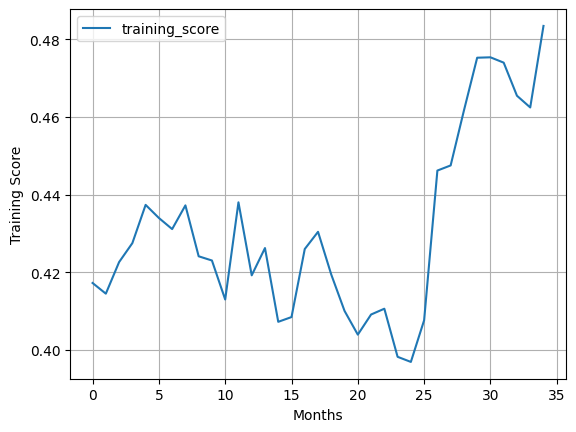

In [ ]:
steps=[('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor())]
param_grid = {
    'regressor__n_estimators': [ 100],  # Regularization strength
    'regressor__max_depth': [3],
}
history_all,val_r2, train_loss,val_loss, train_r2, test_preds, test_loss ,test_r2, tree_model, XlearnT, XvalT = rolling_window_training(steps,param_grid,unique_trade_date, data,validation_size, training_size)

#performance
test_df.reset_index(drop=True, inplace=True)
test_df['expected_target'] = pd.concat(test_preds).reset_index(drop=True)
print('Average Train Loss= {:.2}'.format(np.mean(train_loss)))
print('Average Validation Loss = {:.2}'.format(np.mean(val_loss)))
print('Test Loss = {:.2}'.format(root_mean_squared_error(test_df['target'], test_df['expected_target'])))
print('Train R2 Min= {:.2}% and Max= {:.2}%'.format(np.min(train_r2)*100,np.max(train_r2)*100))
print('Validation R2 = {:.2}% and Max= {:.2}%'.format(np.mean(val_r2)*100,np.max(val_r2)*100))
print('Test R2 = {:.2}%'.format(r2_score(test_df['target'], test_df['expected_target'])*100))
def plot_loss(history):
  plt.plot(history, label='training_score')
  #plt.ylim([0, 10])
  plt.xlabel('Months')
  plt.ylabel('Training Score')
  plt.legend()
  plt.grid(True)
plot_loss(history_all)

PermutationExplainer explainer: 1441it [06:52,  3.42it/s]


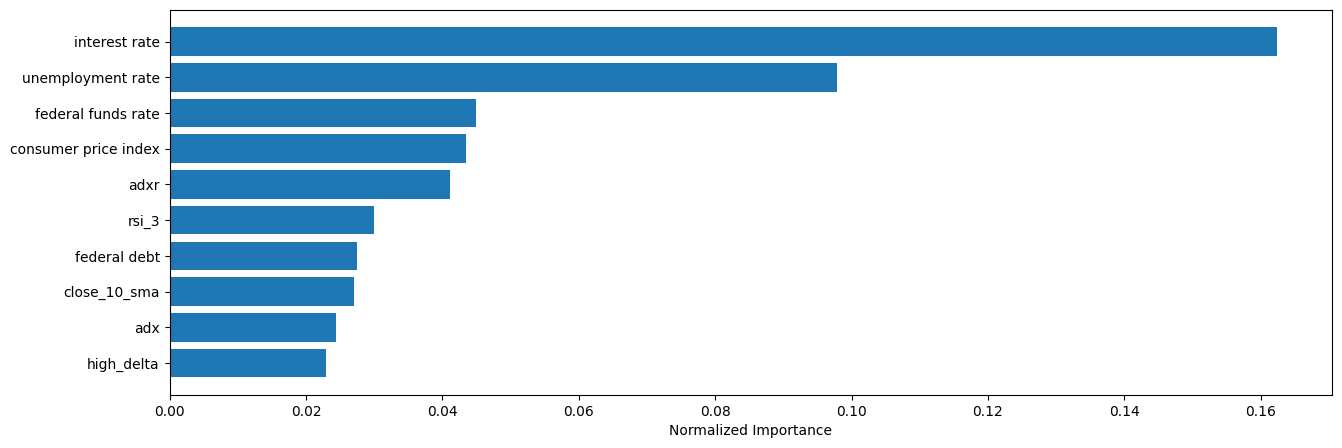

In [ ]:
# Use SHAP to explain the model's predictions
explainer = shap.Explainer(tree_model.predict, XlearnT)
shap_values = explainer.shap_values(XvalT)
#Normaliz shap values
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)
# Normalize the feature importances to sum to 1
normalized_importances = mean_abs_shap_values / np.sum(mean_abs_shap_values)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': normalized_importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 normalized feature importances
top_features = importance_df.head(10)
plt.figure(figsize=(15, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Normalized Importance')
#plt.title('Top 10 Normalized Feature Importances')
plt.gca().invert_yaxis()
plt.savefig('tree_importance.png')
plt.show()

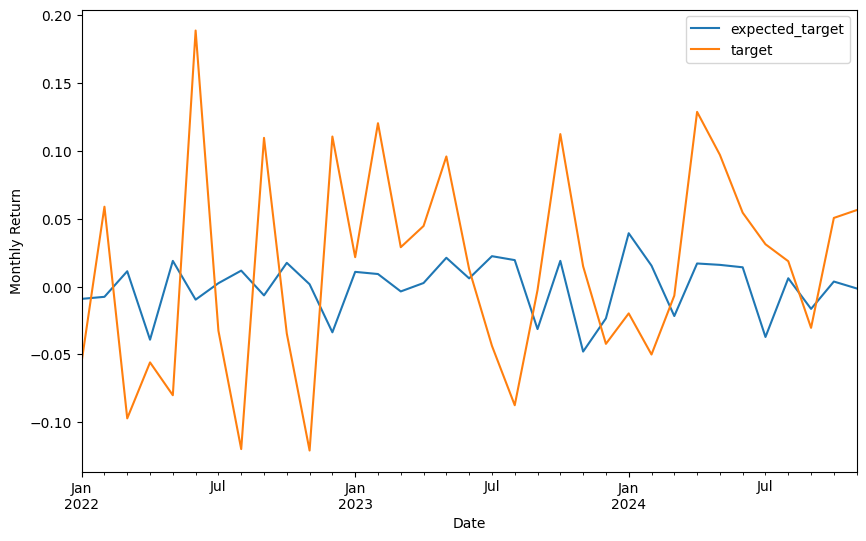

In [ ]:
ax = test_df[test_df.Ticker == 'AAPL'].plot.line(y=["expected_target",'target'], x='Date', ylabel='Monthly Return',xlabel = 'Date', figsize=(10, 6))
fig = ax.get_figure()
fig.savefig('tree_returns.png')

In [ ]:
test_df.to_pickle('datasets/test_data_m1_result_decision_tree.pkl')